# Supervised Modeling
Includes Linear, Ridge, Random Forest, Gradient Boosting, and SVM

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR


In [3]:

df = pd.read_csv("../data/spotify_data_clean.csv")
df.head()


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [4]:

df["release_year"] = pd.to_datetime(df["album_release_date"]).dt.year
df["artist_followers_log"] = np.log1p(df["artist_followers"])
df["artist_impact"] = df["artist_followers_log"] * df["artist_popularity"]

df["explicit"] = df["explicit"].astype(str)

df = df.drop(columns=["track_id", "track_name", "album_id", "album_name", "artist_name", "artist_genres", "album_release_date", "album_type"])
df = df.dropna(subset=["track_popularity"])

y = df["track_popularity"]
X = df.drop(columns=["track_popularity"])


In [5]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:

numeric_features = [
    "artist_popularity",
    "artist_followers",
    "track_duration_min",
    "album_total_tracks",
    "release_year",
    "artist_followers_log",
    "artist_impact"
]

categorical_features = [
    "explicit"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


In [7]:

models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": HistGradientBoostingRegressor(),
    "SVR": SVR()
}


In [8]:

param_grids = {
    "Linear": {},

    "Ridge": {
        "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
    },

    "RandomForest": {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [10, 15, 20, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "GradientBoosting": {
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__max_iter": [100, 200]
    },

    "SVR": {
        "model__C": [0.1, 1, 10, 50],
        "model__kernel": ["rbf"],
        "model__gamma": ["scale", "auto"]
    }
}


In [9]:

results = []

best_rf_model = None

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    if name == "RandomForest":
        best_rf_model = best_model

    preds = best_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "model": name,
        "rmse": rmse,
        "r2": r2,
        "best_params": grid.best_params_
    })

    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("Test RMSE:", rmse)
    print("Test R2:", r2)


Linear
Best Params: {}
Test RMSE: 20.73188733384889
Test R2: 0.27684215848934135

Ridge
Best Params: {'model__alpha': 1.0}
Test RMSE: 20.731863801333038
Test R2: 0.2768438001839383

RandomForest
Best Params: {'model__max_depth': 15, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 600}
Test RMSE: 18.848725798935078
Test R2: 0.4022502365107252

GradientBoosting
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__max_iter': 100}
Test RMSE: 19.192344545793077
Test R2: 0.3802572100161733

SVR
Best Params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Test RMSE: 20.792456493032542
Test R2: 0.2726105084599122


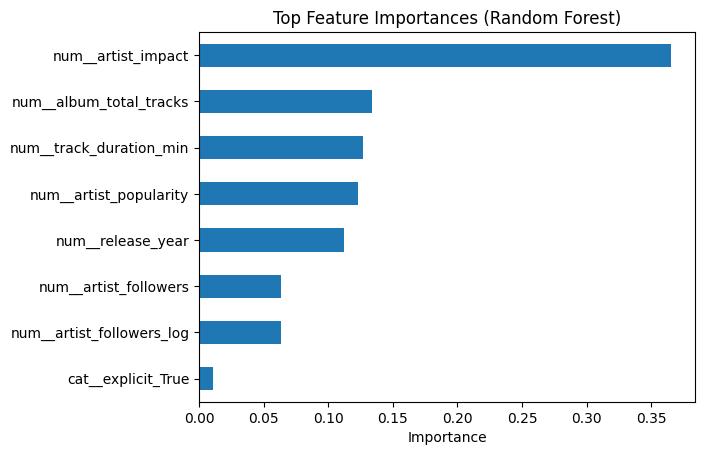

In [10]:
rf_model = best_rf_model.named_steps["model"]

feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(10).plot(kind="barh")
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

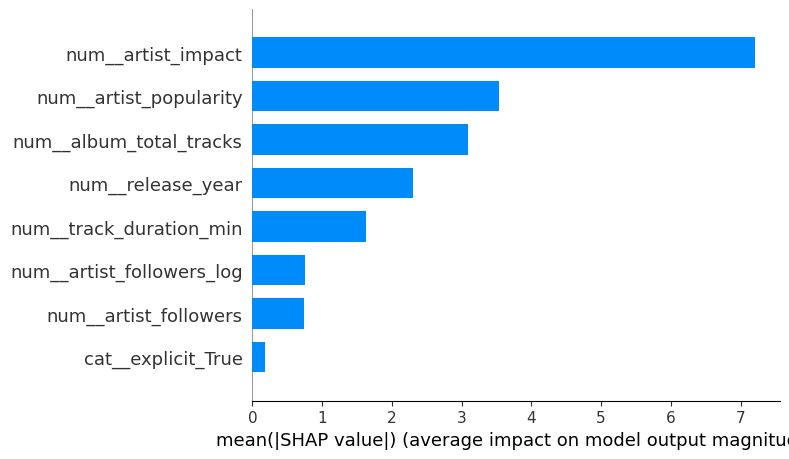

In [11]:
import shap

# Get transformed training data
X_train_transformed = best_rf_model.named_steps["preprocessor"].transform(X_train)

# Convert to DataFrame with feature names
feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()
X_train_df = pd.DataFrame(X_train_transformed, columns=feature_names)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(best_rf_model.named_steps["model"])

# Compute SHAP values
shap_values = explainer.shap_values(X_train_df)

# Summary plot
shap.summary_plot(shap_values, X_train_df, plot_type="bar")